In [1]:
include("CRD_STA.jl")
using Plots
using LinearAlgebra
using NonlinearEigenproblems
using DelimitedFiles
using PyCall

In [3]:
N_cheb = 99
Mr = 0.1
gamma = 1.4
sigma = 0.72
Ro = -1
Co = 2 - Ro - Ro ^ 2
Tw = 1
R = 285.36
Ma = Mr/R
omega = 0
be1 = 0.07759
c = 0.38
u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co);
H,T = T_ca(Mr,f,q,w0,gamma,Tw);
F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim");
lam = - (2/3) * T;
kappa = (1/sigma) * T;
A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be1,N_cheb,Ro,Co)
nep = PEP([A0,A1,A2]); 
eigval,eigvec = iar(nep,σ = c , neigs = 1 ,maxit = 500,tol=1e-10)
eigval

1-element Vector{ComplexF64}:
 0.3866282513898316 - 0.0001280022143035767im

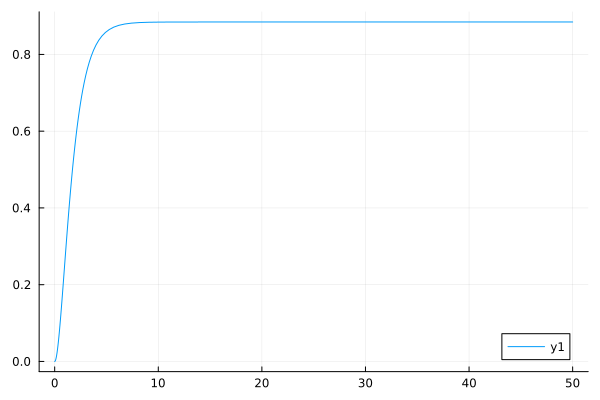

In [30]:
plot(x,H)

In [ ]:
##DIRECTLY CACULATE CUR
##initial
# for omega = [0.048,0.024,-0.024,-0.048]
#     for Mr =  0.3 : 0.3 : 1.2
#         for Tw = 0.8 : 0.1 : 1.2
            omega = 0
            Mr = 0.3
            Tw = 1
            N_cheb = 69
            gamma = 1.4
            sigma = 0.72
            global R = 500
            R_step = 0.5
            be1 = 0.04
            be_step = -0.001
            c = 0.08
            num = 1
            Ro = -1
            Co = 2-Ro-Ro^2
            Ma = Mr/R
            global u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
            H,T = T_ca(Mr,f,q,w0,gamma,Tw)
            F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
            lam = - (2/3) * T
            kappa = (1/sigma) * T
            global initial_i = []
            global initial_r = []
            global tempvec_i = [0 0 0 0]
            global tempvec_r = [0 0 0 0]
            global mode = 0
            writedlm("output_$Tw _ $Mr.dat",initial_i)
            writedlm("output_eig.dat",initial_r)
            A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be1,N_cheb,Ro,Co)
            nep = PEP([A0,A1,A2]); 
            eigval,eigvec = iar(nep,σ = c , neigs = 1 ,maxit = 500,tol=1e-10)
            # eigval = conj(eigval)
            if imag(eigval[1]) < 0
                for be = be1 : be_step : 0

                A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
                nep = PEP([A0,A1,A2]); 
                eigval,eigvec = iar(nep,σ = c , neigs = 1 ,maxit = 500,tol=1e-10)
                # eigval = conj(eigval)
                point = filter(x ->  - 0.0005 < imag(x) < 0.0005, eigval)
                open("output_eig.dat", "a") do io
                    write(io,"be=$be,eig=$eigval\n")
                end
                if point != []
                    global initial_i = [omega R be imag(point)]
                    global initial_r = [omega R be real(point)]
                    break
                end
                end
            elseif imag(eigval[1]) > 0
                for be = be1 : -1 * be_step : 0.5

                    A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
                    nep = PEP([A0,A1,A2]); 
                    eigval,eigvec = iar(nep,σ = c , neigs = 1 ,maxit = 500,tol=1e-10)
                    # eigval = conj(eigval)
                    point = filter(x ->  - 0.0005 < imag(x) < 0.0005, eigval)
                    open("output_eig.dat", "a") do io
                        write(io,"be=$be,eig=$eigval\n")
                    end
                    if point != []
                        global initial_i = [omega R be imag(point)]
                        global initial_r = [omega R be real(point)]
                        break
                    end
                end
            end
            global total_r = initial_r
            global total_i = initial_i

        # CACULATE

            for be = initial_r[1,3] +  be_step  :  -1 * be_step : 0.4

                # if total_i[end,2] <40
                #     num = 5
                # else
                #     num = 1
                # end
                num = 1
                A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,total_r[end,2],Ma,omega,be + 2 * be_step,N_cheb,Ro,Co)
                nep = PEP([A0,A1,A2]); 
                eigval_1,eigvec_1 = iar(nep,σ = total_r[end,4] - im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)
                # eigval_1 = conj(eigval_1)
                A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,total_r[end,2],Ma,omega,be - 2 * be_step,N_cheb,Ro,Co)
                nep = PEP([A0,A1,A2]); 
                eigval_2,eigvec_2 = iar(nep,σ = total_r[end,4] - im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)
                # eigval_2 = conj(eigval_2)
                if (imag(eigval_1[1]) < 0 && imag(eigval_2[1]) > 0) || (imag(eigval_1[1]) < 0 && imag(eigval_2[1]) < 0)

                global mode = 1

                elseif (imag(eigval_1[1]) > 0 && imag(eigval_2[1]) < 0) || (imag(eigval_1[1]) > 0 && imag(eigval_2[1]) > 0)

                global mode = 2

                end
                
                if length(total_r[:,1]) > 2 

                grad = abs(( total_r[end,2] - total_r[end - 1,2] ) / ( total_r[end,3] - total_r[end - 1,3] ))
                else

                grad = 0

                end
                

                if mode == 1 



                    for R = total_r[end,2] - 0 * grad * be_step  : R_step : 0
                        Ma = Mr/R
                        A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
                        nep = PEP([A0,A1,A2]); 
                        pre = total_r[end,4] - im * total_i[end,4]
                        eigval,eigvec = iar(nep,σ = pre , neigs = num ,maxit = 500,tol=1e-10)
                        # eigval = conj(eigval)
                        # index = findmin(abs.(imag(eigval)))
                        
                        global tempvec_i = [tempvec_i;[omega R be imag(eigval[1])]]
                        global tempvec_r = [tempvec_r;[omega R be real(eigval[1])]]

                        len = size(tempvec_i,1)

                        open("output_$Tw _ $Mr.dat", "a") do io
                            write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                        end

                        if tempvec_i[end- 1 ,4] * tempvec_i[end,4] < 0

                            global total_r = [total_r;[tempvec_r[end-1,1] tempvec_r[end-1,2] tempvec_r[end-1,3] tempvec_r[end-1,4]]]
                            global total_i = [total_i;[tempvec_i[end-1,1] tempvec_i[end-1,2] tempvec_i[end-1,3] tempvec_i[end-1,4]]]

                            tempvec_i = [0 0 0 0]
                            tempvec_r = [0 0 0 0]
                            
                            break
                        end
                        
                        if len > 25 && abs(tempvec_i[end,4]) > abs(tempvec_i[end-10,4])

                            mode = 2
                            tempvec_i = [0 0 0 0]
                            tempvec_r = [0 0 0 0]
                            break
                            
                        end
                    end        
                end


                if mode == 2

                    for R = total_r[end,2] + 0 * grad * be_step: -R_step : 600
                        Ma = Mr/R
                        A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
                        nep = PEP([A0,A1,A2]); 
                        eigval,eigvec = iar(nep,σ = total_r[end,4] - im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)
                        # eigval = conj(eigval)
                        # index = findmin(abs.(imag(eigval)))
                        global tempvec_i = [tempvec_i;[omega R be imag(eigval[1])]]
                        global tempvec_r = [tempvec_r;[omega R be real(eigval[1])]]



                        len = size(tempvec_i,1)

                        open("output_$Tw _ $Mr.dat", "a") do io
                            write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                        end

                        if tempvec_i[end - 1,4] * tempvec_i[end,4] < 0
                            global total_r = [total_r;[tempvec_r[end-1,1] tempvec_r[end-1,2] tempvec_r[end-1,3] tempvec_r[end-1,4]]]
                            global total_i = [total_i;[tempvec_i[end-1,1] tempvec_i[end-1,2] tempvec_i[end-1,3] tempvec_i[end-1,4]]]
                            global tempvec_i = [0 0 0 0]
                            global tempvec_r = [0 0 0 0]
                            break

                        end

                        if len > 25 && abs(tempvec_i[end,4]) > abs(tempvec_i[end-10,4])

                            global mode = 1
                            global tempvec_i = [0 0 0 0]
                            global tempvec_r = [0 0 0 0]
                            break
                            
                        end
                    end
                end

                if mode == 1
                    
                    for R = total_r[end,2] - 0 * grad * be_step: -R_step : 0
                        Ma = Mr/R

                        if total_i[end,3] == be

                            break

                        end 

                        A0,A1,A2 = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co)
                        nep = PEP([A0,A1,A2]); 
                        eigval,eigvec = iar(nep,σ = total_r[end,4] - im * total_i[end,4] , neigs = num ,maxit = 500,tol=1e-10)
                        # eigval = conj(eigval)
                        # index = findmin(abs.(imag(eigval)))
                        global tempvec_i = [tempvec_i;[omega R be imag(eigval[1])]]
                        global tempvec_r = [tempvec_r;[omega R be real(eigval[1])]]

                        len = size(tempvec_i,1)

                        open("output_$Tw _ $Mr.dat", "a") do io
                            write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                        end

                        if tempvec_i[end - 1,4] * tempvec_i[end,4] < 0
                            global total_r = [total_r;[tempvec_r[end-1,1] tempvec_r[end-1,2] tempvec_r[end-1,3] tempvec_r[end-1,4]]]
                            global total_i = [total_i;[tempvec_i[end-1,1] tempvec_i[end-1,2] tempvec_i[end-1,3] tempvec_i[end-1,4]]]
                            global tempvec_i = [0 0 0 0]
                            global tempvec_r = [0 0 0 0]
                            break
                        end
                        
                        if len > 25 && abs(tempvec_i[end,4]) > abs(tempvec_i[end-10,4])

                        global mode = 2
                        global tempvec_i = [0 0 0 0]
                        global tempvec_r = [0 0 0 0]
                            break
                            
                        end

                    end     
                end
        
                if total_i[end,2]>210 && size(total_i,1)>50
                    break
                end
                # if total_i[end,2]>total_i[end-1,2]
                #     break
                # end

            end

            writedlm("$omega _$Tw _$Mr _i.dat",total_i)
            writedlm("$omega _$Tw _$Mr _r.dat",total_r)

    #         end
    #     end
    # end